# **Coin Detection, Classification, and Counting**

## Image Processing and Computer Vision - Assignment Module #1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

## Task
You are given a dataset of photographs containing coins.

Your goal is to build a pipeline that, given an image, detects all coins present, identifies their denomination, and computes the total monetary value shown in the image.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

### Example of expected output
```
.
.
.
image_85.jpg - 5 coin(s) found:
  Coin 1 {value: 1.000}
  Coin 2 {value: 0.200}
  Coin 3 {value: 0.100}
  Coin 4 {value: 2.000}
  Coin 5 {value: 0.050}
  Partial Amount {value: 3.350}
image_86.jpg - 3 coin(s) found:
.
.
.
```

## Data
Two folders of images are provided:
* `reference_set`: eight images, one per coin denomination, each containing a single coin. These images come with a label (their file name is their denomination value) and serve as your reference data. Use them to build and calibrate your classifier;
* `target_set`: a collection of images each containing one or more coins, with no labels. Your pipeline must process each image and output the total monetary value of the coins present.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip ./
# !unzip coin_dataset.zip

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and **comment every important step**;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach **and justify every decision you make**;

3. **Results correctness**. Both instance-level and total monetary value will be evaluated. Note that a thoroughly justified and sound procedure with a lower number of solved instances will be valued more than an unjustified procedure with lucky outputs.

## 1. Solution overview

The previous classifier was too much of a black box.  In this version I make each decision visible.

The method uses only the labelled reference images and classical computer vision:

1. detect circular candidates with Hough circles;
2. score candidates with local contrast and edge evidence;
3. crop every reference coin and target coin;
4. extract SIFT keypoints and descriptors;
5. compute material/ring features from each coin crop;
6. classify all coins in one image by combining SIFT evidence, material evidence, and physical-size consistency;
7. visualize every important step: reference circles, reference keypoints, target circles, feature table, SIFT matches, and final overlays.

The geometry prior is based on known euro coin diameters.  This is not a target-image label; it is fixed knowledge about the coin system, like knowing that the objects are circular.

In [2]:
from pathlib import Path
import random
import re
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

REFERENCE_DIR = Path("coin_dataset/reference_set")
TARGET_DIR = Path("coin_dataset/target_set2")

COIN_VALUES_CENTS = {
    "1cent": 1,
    "2cent": 2,
    "5cent": 5,
    "10cent": 10,
    "20cent": 20,
    "50cent": 50,
    "1euro": 100,
    "2euro": 200,
}

# Physical diameters in millimetres.  These make the classifier reason about
# relative size inside one image instead of guessing each crop independently.
COIN_DIAMETERS_MM = {
    "1cent": 16.25,
    "2cent": 18.75,
    "5cent": 21.25,
    "10cent": 19.75,
    "20cent": 22.25,
    "50cent": 24.25,
    "1euro": 23.25,
    "2euro": 25.75,
}

CLASS_NAMES = list(COIN_VALUES_CENTS.keys())

print("Reference images:", len(list(REFERENCE_DIR.glob("*.jpg"))))
print("Target images:", len(list(TARGET_DIR.glob("*.jpg"))))

Reference images: 8
Target images: 142


## 2. Small helper functions

In [3]:
def normalize_label(text):
    """Convert filenames such as '2_euro' or '50cent' to compact labels."""
    text = str(text).lower().replace("_", "").replace(" ", "")
    return text.replace("cents", "cent")


def image_number(path):
    """Sort image_2.jpg before image_10.jpg."""
    match = re.search(r"(\d+)", Path(path).stem)
    return int(match.group(1)) if match else 10**9


def cents_to_euro(cents):
    """Display cents as euros."""
    return cents / 100.0


def read_bgr(path):
    """Read an OpenCV BGR image and fail loudly if it is missing."""
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    return img


def show_rgb(img_bgr, title=None, size=(7, 7)):
    """Show a single OpenCV image with Matplotlib."""
    plt.figure(figsize=size)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## 3. Initial visual inspection

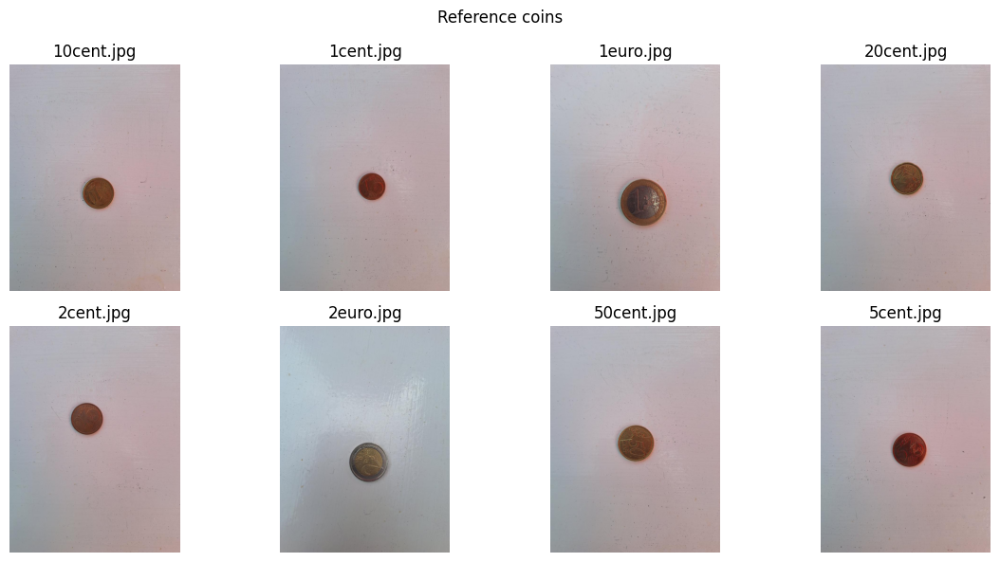

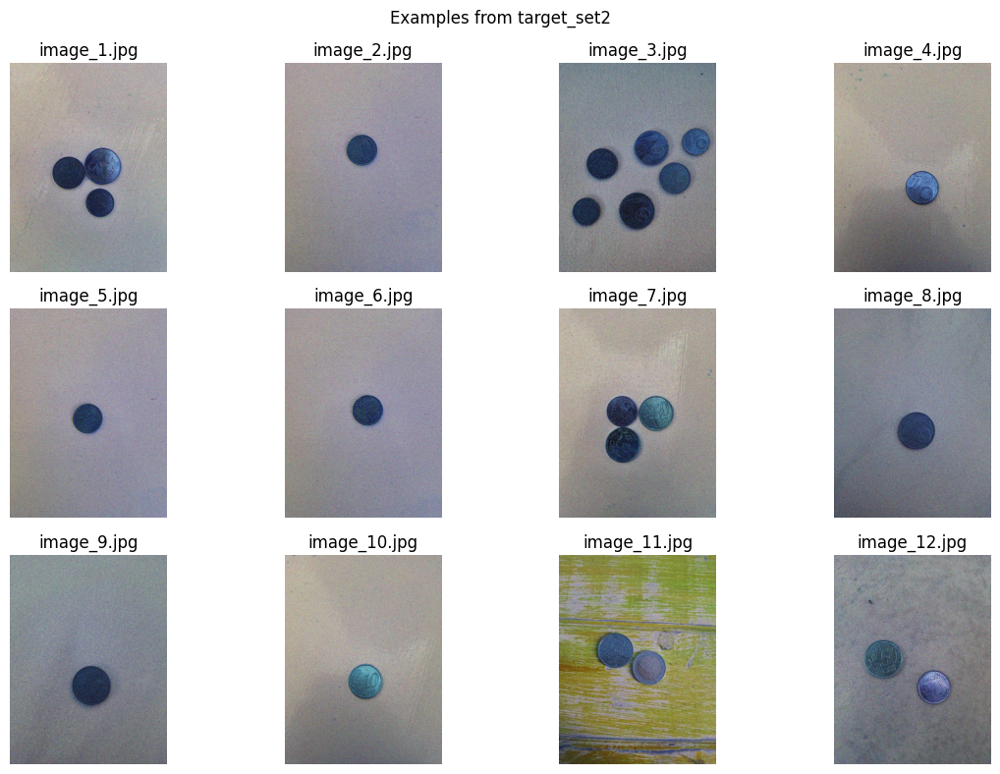

In [4]:
def show_image_grid(paths, title, cols=4, size=(12, 7)):
    paths = list(paths)
    rows = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=size)
    for i, path in enumerate(paths, start=1):
        img = cv2.cvtColor(read_bgr(path), cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(Path(path).name)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


reference_paths = sorted(REFERENCE_DIR.glob("*.jpg"))
target_paths = sorted(TARGET_DIR.glob("*.jpg"), key=image_number)

show_image_grid(reference_paths, "Reference coins", cols=4, size=(12, 6))
show_image_grid(target_paths[:12], "Examples from target_set2", cols=4, size=(12, 8))

## 4. Coin circle detection

I use Hough circles for candidate generation, then remove weak circular noise using local objectness.  A true coin should have contrast against its surrounding background and a visible circular boundary.

In [5]:
def hough_coin_candidates(img_bgr, param2=42):
    """Generate circular candidates with HoughCircles."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.5,
        minDist=45,
        param1=100,
        param2=param2,
        minRadius=25,
        maxRadius=110,
    )
    if circles is None:
        return []

    raw = sorted(np.round(circles[0]).astype(int), key=lambda c: c[2], reverse=True)
    filtered = []
    for x, y, r in raw:
        duplicate = False
        for x2, y2, r2 in filtered:
            if np.hypot(x - x2, y - y2) < 0.55 * max(r, r2):
                duplicate = True
                break
        if not duplicate:
            filtered.append((int(x), int(y), int(r)))
    return filtered


def candidate_objectness_scores(img_bgr, candidates):
    """Score a Hough circle using contrast and edge density."""
    height, width = img_bgr.shape[:2]
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 1), 70, 150)
    yy, xx = np.ogrid[:height, :width]

    scored = []
    for x, y, r in candidates:
        # Reject circles that are visibly clipped by the image border.  These
        # are usually background objects or table edges, not complete coins.
        border_margin = min(x - r, y - r, width - 1 - (x + r), height - 1 - (y + r))
        if border_margin < -0.03 * r:
            scored.append((int(x), int(y), int(r), -1.0))
            continue

        distance = np.sqrt((xx - x) ** 2 + (yy - y) ** 2)
        inside = distance <= 0.78 * r
        outside = (distance >= 1.05 * r) & (distance <= 1.35 * r)
        boundary = (distance >= 0.82 * r) & (distance <= 1.08 * r)

        if inside.sum() < 50 or outside.sum() < 50:
            score = -1.0
        else:
            color_contrast = np.linalg.norm(np.median(lab[inside], axis=0) - np.median(lab[outside], axis=0))
            gray_contrast = abs(float(np.median(gray[inside])) - float(np.median(gray[outside])))
            boundary_edges = float(edges[boundary].mean()) / 255.0
            inner_edges = float(edges[inside].mean()) / 255.0
            score = 0.9 * color_contrast + 0.6 * gray_contrast + 45.0 * boundary_edges + 8.0 * inner_edges

        scored.append((int(x), int(y), int(r), float(score)))
    return scored


def select_coin_detections(img_bgr, score_threshold=15):
    """Final circle detector: Hough candidates + objectness + non-maximum suppression."""
    candidates = hough_coin_candidates(img_bgr)
    scored = candidate_objectness_scores(img_bgr, candidates)
    scored = sorted([c for c in scored if c[3] >= score_threshold], key=lambda c: c[3], reverse=True)

    selected = []
    for x, y, r, score in scored:
        overlaps = False
        for x2, y2, r2, _ in selected:
            if np.hypot(x - x2, y - y2) < 0.70 * max(r, r2):
                overlaps = True
                break
        if not overlaps:
            selected.append((x, y, r, score))
    return selected


def draw_circles(img_bgr, detections, labels=None):
    """Draw detected circles and optional text labels."""
    canvas = img_bgr.copy()
    labels = labels or [""] * len(detections)
    for i, ((x, y, r, score), label) in enumerate(zip(detections, labels), start=1):
        cv2.circle(canvas, (x, y), r, (0, 255, 0), 3)
        cv2.circle(canvas, (x, y), 3, (0, 0, 255), -1)
        text = label if label else f"{i}"
        cv2.putText(canvas, text, (x - r, max(20, y - r - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 0, 0), 2, cv2.LINE_AA)
    return canvas

### Step 1 output: circles found in the reference images

This verifies that the reference crop is taken from the real coin and not from the background.

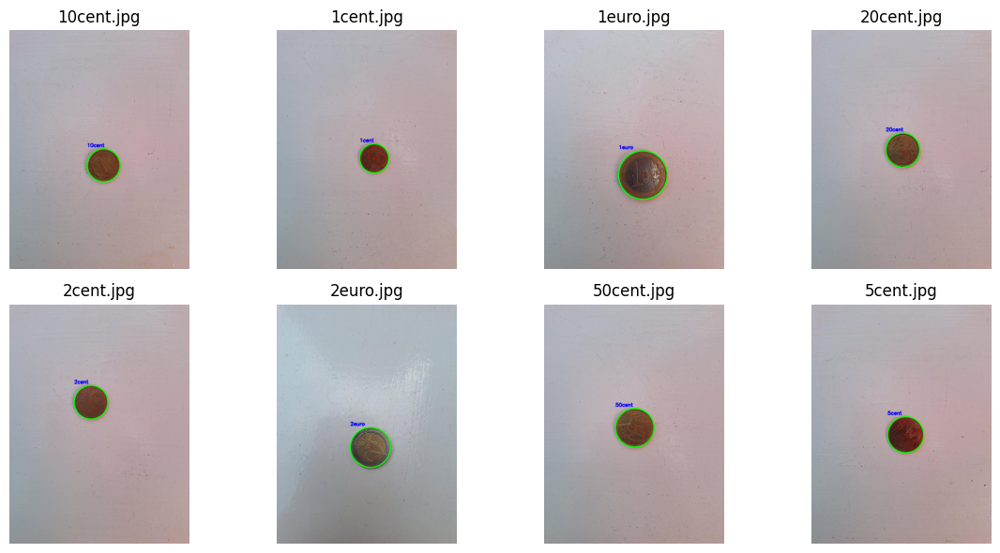

In [6]:
def reference_detection(path):
    """Detect the single reference coin.  The lower threshold is safe here because the image contains one coin."""
    img = read_bgr(path)
    detections = select_coin_detections(img, score_threshold=5)
    if not detections:
        raise RuntimeError(f"No coin found in {path.name}")
    return max(detections, key=lambda d: d[2])


reference_detections = {normalize_label(path.stem): reference_detection(path) for path in reference_paths}


plt.figure(figsize=(12, 6))
for i, path in enumerate(reference_paths, start=1):
    label = normalize_label(path.stem)
    img = draw_circles(read_bgr(path), [reference_detections[label]], [label])
    plt.subplot(2, 4, i)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Normalized coin crops, material features, and keypoints

The first SIFT version compared target crops and reference crops after slightly different resizing.  That makes the debug matches visually confusing and also hurts descriptor repeatability.

Here every detected coin is first converted to the same normalized view:

1. the detected centre is moved to the image centre;
2. the detected radius is scaled to a fixed radius;
3. the same grayscale enhancement and circular masks are used for reference and target coins.

SIFT is still shown explicitly, but the final keypoint evidence also uses ORB as a binary keypoint backup because the target images contain strong sensor noise.  Both are traditional local-feature methods.

In [113]:
# All reference and target coins are warped to this same view before feature extraction.
NORMALIZED_COIN_SIZE = 256
NORMALIZED_COIN_RADIUS = 94
SIFT_MASK_RADIUS = int(NORMALIZED_COIN_RADIUS * 0.72)
ORB_MASK_RADIUS = int(NORMALIZED_COIN_RADIUS * 0.86)
TEMPLATE_ANGLES = list(range(0, 360, 15))

SIFT_RATIO = 0.80
ORB_RATIO = 0.78


def make_circular_mask(size, radius):
    """Create a centred circular mask."""
    mask = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(mask, (size // 2, size // 2), int(radius), 255, -1)
    return mask


SIFT_MASK = make_circular_mask(NORMALIZED_COIN_SIZE, SIFT_MASK_RADIUS)
ORB_MASK = make_circular_mask(NORMALIZED_COIN_SIZE, ORB_MASK_RADIUS)
TEMPLATE_MASK = ORB_MASK.copy()
TEMPLATE_MASK_BOOL = TEMPLATE_MASK > 0


def crop_coin(img_bgr, x, y, r, padding=None):
    """Return an affine-normalized coin view.

    The old code cropped a square around each coin.  A square crop changes the
    apparent coin size when the padding changes.  This version uses the Hough
    centre/radius to place every coin in the same coordinate frame, so SIFT sees
    reference and target coins at the same scale.
    """
    scale = NORMALIZED_COIN_RADIUS / float(r)
    center = NORMALIZED_COIN_SIZE / 2.0
    transform = np.array([
        [scale, 0, center - scale * x],
        [0, scale, center - scale * y],
    ], dtype=np.float32)

    return cv2.warpAffine(
        img_bgr,
        transform,
        (NORMALIZED_COIN_SIZE, NORMALIZED_COIN_SIZE),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REFLECT101,
    )


def normalized_gray_patch(crop_bgr, size=NORMALIZED_COIN_SIZE, mask_radius=SIFT_MASK_RADIUS):
    """Preprocess one normalized crop for RootSIFT.

    This function is used for both reference coins and target coins.  The mask is
    intentionally a little smaller than the full coin so noisy borders and cast
    shadows do not dominate the SIFT descriptors.
    """
    if crop_bgr.shape[:2] != (size, size):
        crop_bgr = cv2.resize(crop_bgr, (size, size), interpolation=cv2.INTER_CUBIC)
#######################################################################################################################################
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    gray = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8)).apply(gray)
    mask = make_circular_mask(size, mask_radius)
    return gray, mask


def normalized_orb_patch(crop_bgr, size=NORMALIZED_COIN_SIZE, mask_radius=ORB_MASK_RADIUS):
    """Preprocess one normalized crop for ORB and template comparison.

    ORB benefits from keeping the full coin design, while bilateral filtering
    reduces the target-set noise without blurring the main relief edges.
    """
    if crop_bgr.shape[:2] != (size, size):
        crop_bgr = cv2.resize(crop_bgr, (size, size), interpolation=cv2.INTER_CUBIC)

#######################################################################################################################################
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 5, 25, 25)
    gray = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8)).apply(gray)
    mask = make_circular_mask(size, mask_radius)
    return gray, mask


# def normalized_gradient_patch(crop_bgr):
#     """Build a rotation-comparable gradient image for template similarity."""
# #######################################################################################################################################
#     gray, _ = normalized_orb_patch(crop_bgr)
#     grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
#     grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
#     magnitude = cv2.magnitude(grad_x, grad_y)
#     return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.float32)

def normalized_gradient_patch(crop_bgr):
    gray, _ = normalized_orb_patch(crop_bgr)

    # Extra smoothing before Sobel so random noise is not treated as structure.
    gray = cv2.GaussianBlur(gray, (5, 5), 1.2)

    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    magnitude = cv2.magnitude(grad_x, grad_y)
    return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.float32)

def rotate_image(img, angle):
    """Rotate a normalized patch around its centre."""
    size = img.shape[0]
    matrix = cv2.getRotationMatrix2D((size / 2, size / 2), angle, 1.0)
    return cv2.warpAffine(
        img,
        matrix,
        (size, size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT101,
    )


def masked_normalized_vector(img, mask_bool=TEMPLATE_MASK_BOOL):
    """Convert a masked image into a zero-mean unit vector for correlation."""
    values = img[mask_bool].astype(np.float32)
    values = values - values.mean()
    return values / (np.linalg.norm(values) + 1e-6)


def rootsift(descriptors):
    """Convert SIFT descriptors to RootSIFT descriptors.

    RootSIFT keeps the SIFT detector/descriptor but compares L1-normalized square
    roots.  It is a common hand-crafted improvement for illumination changes.
    """
    if descriptors is None or len(descriptors) == 0:
        return None
    descriptors = descriptors.astype(np.float32)
    descriptors /= descriptors.sum(axis=1, keepdims=True) + 1e-7
    return np.sqrt(descriptors)


def coin_material_features(img_bgr, detection):
    """Measure centre/ring colour statistics directly from the original image."""
    x, y, r, score = detection
    height, width = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    yy, xx = np.ogrid[:height, :width]
    distance = np.sqrt((xx - x) ** 2 + (yy - y) ** 2)

    masks = {
        "center": distance < 0.35 * r,
        "outer": (distance >= 0.65 * r) & (distance < 0.92 * r),
        "all": distance < 0.90 * r,
        "background": (distance > 1.10 * r) & (distance < 1.40 * r),
    }

    f = {"x": x, "y": y, "r": r, "objectness": score}
    for name, mask in masks.items():
        f[f"{name}_h"] = float(np.median(hsv[mask, 0]))
        f[f"{name}_s"] = float(np.median(hsv[mask, 1]))
        f[f"{name}_v"] = float(np.median(hsv[mask, 2]))
        f[f"{name}_l"] = float(np.median(lab[mask, 0]))
        f[f"{name}_a"] = float(np.median(lab[mask, 1]))
        f[f"{name}_b"] = float(np.median(lab[mask, 2]))

    f["center_minus_outer_s"] = f["center_s"] - f["outer_s"]
    f["outer_minus_center_s"] = f["outer_s"] - f["center_s"]
    f["center_minus_outer_b"] = f["center_b"] - f["outer_b"]
    f["outer_minus_center_b"] = f["outer_b"] - f["center_b"]
    f["center_outer_lab_distance"] = float(np.linalg.norm([
        f["center_l"] - f["outer_l"],
        f["center_a"] - f["outer_a"],
        f["center_b"] - f["outer_b"],
    ]))
    return f


# SIFT remains the main floating-point descriptor.  ORB is an additional
# traditional keypoint descriptor that is more robust on these noisy targets.
sift = cv2.SIFT_create(
    nfeatures=1500,
    nOctaveLayers=3,
    contrastThreshold=0.012,
    edgeThreshold=10,
    sigma=1.4,
)

FLANN_INDEX_KDTREE = 1
sift_matcher = cv2.FlannBasedMatcher(
    dict(algorithm=FLANN_INDEX_KDTREE, trees=5),
    dict(checks=80),
)
matcher = sift_matcher

orb = cv2.ORB_create(
    nfeatures=2500,
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=15,
    patchSize=31,
    fastThreshold=7,
)
orb_matcher = cv2.BFMatcher(cv2.NORM_HAMMING)

### Step 1.5 output: visual check for every function in Section 5

This debug cell calls each helper function once.  If the function creates or changes an image, the notebook shows the image before and after.  If the result is numeric, the notebook prints a compact text/table summary.


Demo inputs
Reference: 2euro circle = (374, 575, 80, 124.8)
Target: image_139.jpg chosen circle = (368, 407, 75, 101.97)


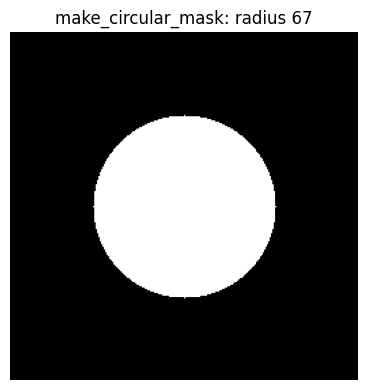

make_circular_mask output: {'shape': (256, 256), 'dtype': 'uint8', 'white_pixels': 14073}


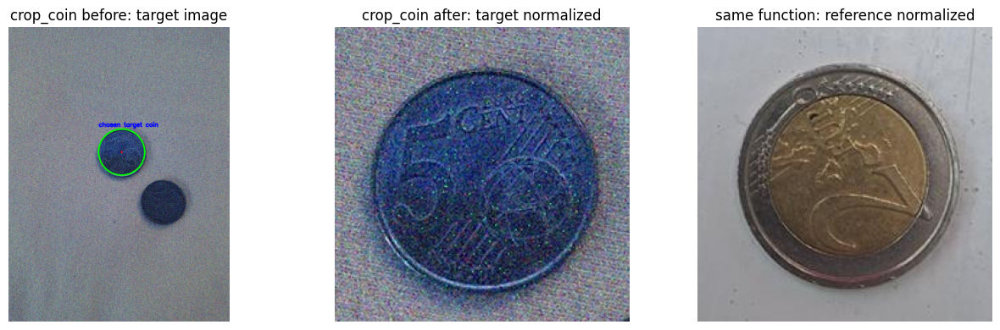

crop_coin output shapes: {'target_crop': (256, 256, 3), 'reference_crop': (256, 256, 3)}


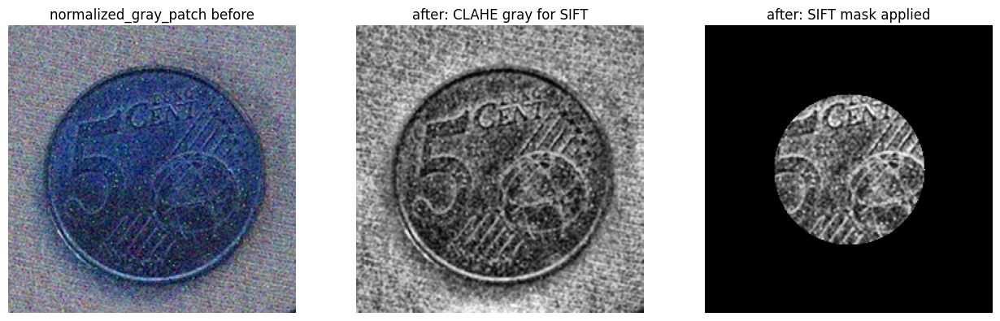

normalized_gray_patch output: {'gray_shape': (256, 256), 'gray_min_max': (6, 250), 'mask_white_pixels': 14073}


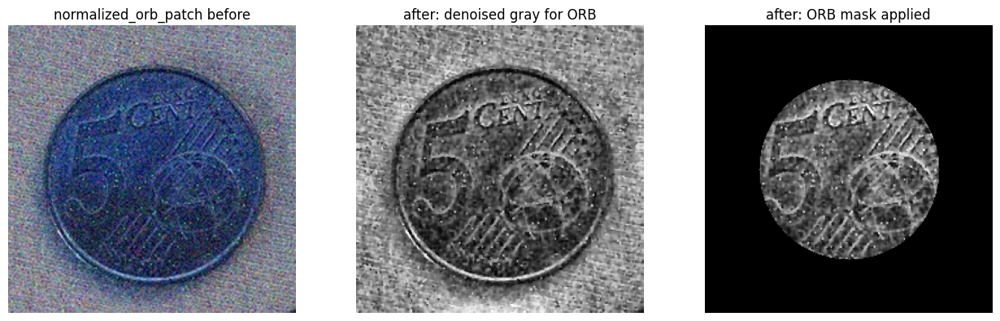

normalized_orb_patch output: {'gray_shape': (256, 256), 'gray_min_max': (7, 251), 'mask_white_pixels': 20081}


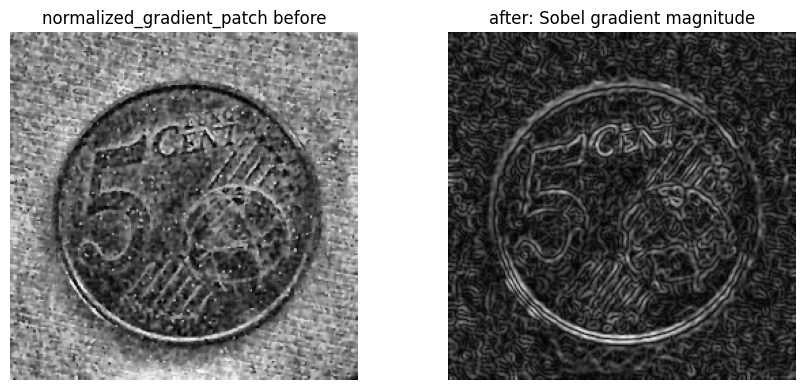

normalized_gradient_patch output: {'shape': (256, 256), 'dtype': 'float32', 'min_max': (0.0, 255.00001525878906)}


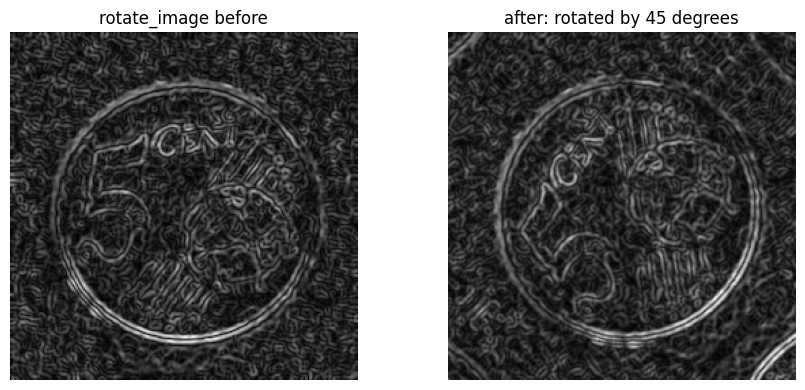

rotate_image output: {'input_shape': (256, 256), 'rotated_shape': (256, 256)}
masked_normalized_vector output:
  vector length: 20081
  vector mean after normalization: -0.0
  vector L2 norm: 1.0
  first 8 values: [ 0.0058 -0.0053  0.0006  0.0077  0.0119  0.0138  0.0073 -0.0009]
rootsift output:
  keypoints detected before RootSIFT: 424
  raw descriptor shape: (424, 128)
  RootSIFT descriptor shape: (424, 128)
  first raw descriptor values: [11. 19.  9. 29. 13.  2. 15. 72.]
  first RootSIFT descriptor values: [0.054 0.071 0.049 0.088 0.059 0.023 0.063 0.138]


,feature,value
0,x,368.000
1,y,407.000
2,r,75.000
3,objectness,101.969
4,center_h,111.000
5,center_s,164.000
6,center_v,108.000
7,center_l,65.000
8,center_a,137.000
9,center_b,97.000


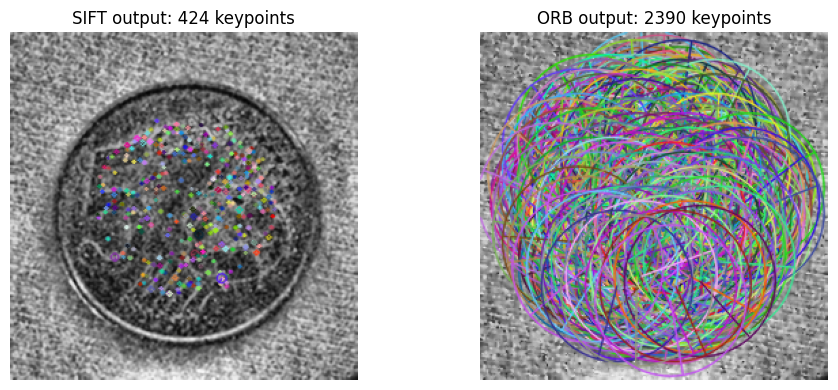

Detector/matcher objects:
  SIFT matcher: FLANN KD-tree, ratio threshold = 0.8
  ORB matcher: brute-force Hamming, ratio threshold = 0.78
  ORB descriptors shape: (2390, 32)


In [114]:
# Demonstration inputs for the Section 5 helper functions.
# I use one clean reference coin and one noisy target coin so the effect of each
# preprocessing step is visible.
DEMO_REFERENCE_LABEL = "2euro"
DEMO_TARGET_IMAGE = TARGET_DIR / "image_139.jpg"

reference_demo_img = read_bgr(REFERENCE_DIR / f"{DEMO_REFERENCE_LABEL}.jpg")
reference_demo_detection = reference_detections[DEMO_REFERENCE_LABEL]

target_demo_img = read_bgr(DEMO_TARGET_IMAGE)
target_demo_detections = select_coin_detections(target_demo_img)
target_demo_detection = max(target_demo_detections, key=lambda d: d[2])


def show_debug_images(images, titles, size=(12, 4), cmaps=None):
    """Small display helper used only for this debug section."""
    cmaps = cmaps or [None] * len(images)
    plt.figure(figsize=size)
    for i, (img, title, cmap) in enumerate(zip(images, titles, cmaps), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap or "gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


print("Demo inputs")
print("Reference:", DEMO_REFERENCE_LABEL, "circle =", tuple(round(v, 2) for v in reference_demo_detection))
print("Target:", DEMO_TARGET_IMAGE.name, "chosen circle =", tuple(round(v, 2) for v in target_demo_detection))

# 1) make_circular_mask: image output plus text summary.
demo_mask = make_circular_mask(NORMALIZED_COIN_SIZE, SIFT_MASK_RADIUS)
show_debug_images(
    [demo_mask],
    [f"make_circular_mask: radius {SIFT_MASK_RADIUS}"],
    size=(4, 4),
)
print("make_circular_mask output:", {
    "shape": demo_mask.shape,
    "dtype": str(demo_mask.dtype),
    "white_pixels": int(np.count_nonzero(demo_mask)),
})

# 2) crop_coin: before = original image with detected circle, after = normalized crop.
target_circle_before = draw_circles(target_demo_img, [target_demo_detection], ["chosen target coin"])
target_crop = crop_coin(target_demo_img, *target_demo_detection[:3])
reference_crop = crop_coin(reference_demo_img, *reference_demo_detection[:3])
show_debug_images(
    [target_circle_before, target_crop, reference_crop],
    ["crop_coin before: target image", "crop_coin after: target normalized", "same function: reference normalized"],
    size=(13, 4),
)
print("crop_coin output shapes:", {
    "target_crop": target_crop.shape,
    "reference_crop": reference_crop.shape,
})

# 3) normalized_gray_patch: before = normalized colour crop, after = SIFT grayscale and mask.
sift_gray, sift_mask = normalized_gray_patch(target_crop)
sift_masked = cv2.bitwise_and(sift_gray, sift_gray, mask=sift_mask)
show_debug_images(
    [target_crop, sift_gray, sift_masked],
    ["normalized_gray_patch before", "after: CLAHE gray for SIFT", "after: SIFT mask applied"],
    size=(13, 4),
    cmaps=[None, "gray", "gray"],
)
print("normalized_gray_patch output:", {
    "gray_shape": sift_gray.shape,
    "gray_min_max": (int(sift_gray.min()), int(sift_gray.max())),
    "mask_white_pixels": int(np.count_nonzero(sift_mask)),
})

# 4) normalized_orb_patch: before = normalized colour crop, after = ORB grayscale and mask.
orb_gray, orb_mask = normalized_orb_patch(target_crop)
orb_masked = cv2.bitwise_and(orb_gray, orb_gray, mask=orb_mask)
show_debug_images(
    [target_crop, orb_gray, orb_masked],
    ["normalized_orb_patch before", "after: denoised gray for ORB", "after: ORB mask applied"],
    size=(13, 4),
    cmaps=[None, "gray", "gray"],
)
print("normalized_orb_patch output:", {
    "gray_shape": orb_gray.shape,
    "gray_min_max": (int(orb_gray.min()), int(orb_gray.max())),
    "mask_white_pixels": int(np.count_nonzero(orb_mask)),
})

# 5) normalized_gradient_patch: before = ORB grayscale, after = Sobel gradient magnitude.
gradient_patch = normalized_gradient_patch(target_crop)
show_debug_images(
    [orb_gray, gradient_patch],
    ["normalized_gradient_patch before", "after: Sobel gradient magnitude"],
    size=(9, 4),
    cmaps=["gray", "gray"],
)
print("normalized_gradient_patch output:", {
    "shape": gradient_patch.shape,
    "dtype": str(gradient_patch.dtype),
    "min_max": (float(gradient_patch.min()), float(gradient_patch.max())),
})

# 6) rotate_image: before = gradient image, after = rotated gradient image.
rotated_gradient = rotate_image(gradient_patch, 45)
show_debug_images(
    [gradient_patch, rotated_gradient],
    ["rotate_image before", "after: rotated by 45 degrees"],
    size=(9, 4),
    cmaps=["gray", "gray"],
)
print("rotate_image output:", {
    "input_shape": gradient_patch.shape,
    "rotated_shape": rotated_gradient.shape,
})

# 7) masked_normalized_vector: text output because the result is a 1D numeric vector.
template_vector = masked_normalized_vector(gradient_patch)
print("masked_normalized_vector output:")
print("  vector length:", len(template_vector))
print("  vector mean after normalization:", round(float(template_vector.mean()), 6))
print("  vector L2 norm:", round(float(np.linalg.norm(template_vector)), 6))
print("  first 8 values:", np.round(template_vector[:8], 4))

# 8) rootsift: text output because descriptors are numeric arrays.
raw_sift_keypoints, raw_sift_descriptors = sift.detectAndCompute(sift_gray, sift_mask)
root_sift_descriptors = rootsift(raw_sift_descriptors)
print("rootsift output:")
print("  keypoints detected before RootSIFT:", len(raw_sift_keypoints))
if raw_sift_descriptors is None:
    print("  no SIFT descriptors found")
else:
    print("  raw descriptor shape:", raw_sift_descriptors.shape)
    print("  RootSIFT descriptor shape:", root_sift_descriptors.shape)
    print("  first raw descriptor values:", np.round(raw_sift_descriptors[0, :8], 3))
    print("  first RootSIFT descriptor values:", np.round(root_sift_descriptors[0, :8], 3))

# 9) coin_material_features: table output because it returns a dictionary of numbers.
material_features = coin_material_features(target_demo_img, target_demo_detection)
material_rows = [
    {"feature": key, "value": round(value, 3) if isinstance(value, float) else value}
    for key, value in material_features.items()
]
display(pd.DataFrame(material_rows))

# 10) SIFT and ORB detectors: text summary and keypoint images.
orb_keypoints, orb_descriptors = orb.detectAndCompute(orb_gray, orb_mask)
sift_keypoint_img = cv2.drawKeypoints(
    sift_gray,
    raw_sift_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)
orb_keypoint_img = cv2.drawKeypoints(
    orb_gray,
    orb_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)
show_debug_images(
    [sift_keypoint_img, orb_keypoint_img],
    [f"SIFT output: {len(raw_sift_keypoints)} keypoints", f"ORB output: {len(orb_keypoints)} keypoints"],
    size=(10, 4),
    cmaps=["gray", "gray"],
)
print("Detector/matcher objects:")
print("  SIFT matcher: FLANN KD-tree, ratio threshold =", SIFT_RATIO)
print("  ORB matcher: brute-force Hamming, ratio threshold =", ORB_RATIO)
print("  ORB descriptors shape:", None if orb_descriptors is None else orb_descriptors.shape)

### Step 2 output: SIFT keypoints on every normalized reference coin

All reference coins below are shown after the same affine normalization and grayscale preprocessing that will be used for target coins.  This makes the later match visualizations easier to interpret: the target and reference images should now look like the same type of processed object.

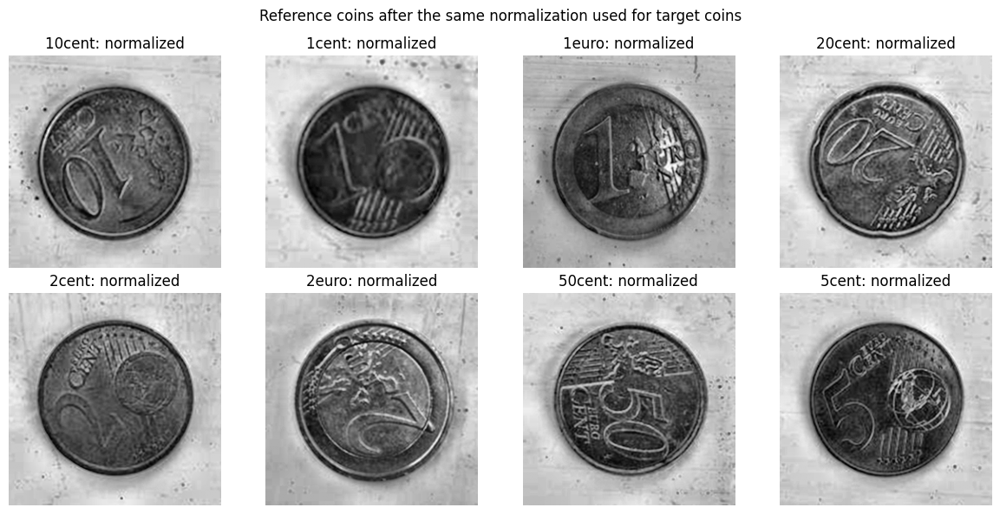

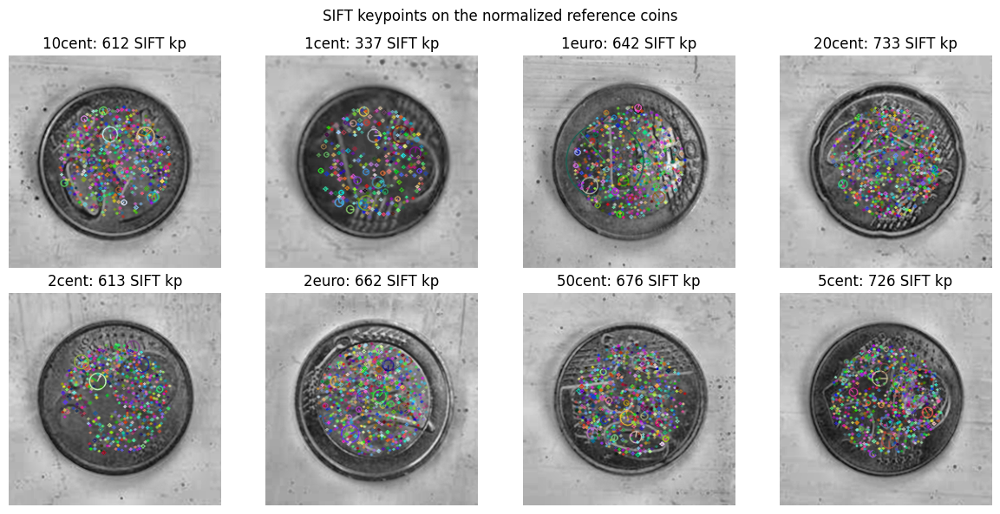

Reference keypoints after identical normalization:
10cent: 612 SIFT keypoints, 2204 ORB keypoints
1cent: 337 SIFT keypoints, 1363 ORB keypoints
1euro: 642 SIFT keypoints, 2214 ORB keypoints
20cent: 733 SIFT keypoints, 2340 ORB keypoints
2cent: 613 SIFT keypoints, 2050 ORB keypoints
2euro: 662 SIFT keypoints, 2287 ORB keypoints
50cent: 676 SIFT keypoints, 2268 ORB keypoints
5cent: 726 SIFT keypoints, 2216 ORB keypoints


In [115]:
reference_db = {}
reference_display_rows = []

for path in reference_paths:
    label = normalize_label(path.stem)
    x, y, r, _ = reference_detections[label]
    crop = crop_coin(read_bgr(path), x, y, r)

    sift_gray, sift_mask = normalized_gray_patch(crop)
    sift_keypoints, sift_descriptors = sift.detectAndCompute(sift_gray, sift_mask)
    sift_descriptors = rootsift(sift_descriptors)

    orb_gray, orb_mask = normalized_orb_patch(crop)
    orb_keypoints, orb_descriptors = orb.detectAndCompute(orb_gray, orb_mask)

    gradient = normalized_gradient_patch(crop)
    template_vectors = [
        masked_normalized_vector(rotate_image(gradient, angle))
        for angle in TEMPLATE_ANGLES
    ]

    reference_db[label] = {
        "path": path,
        "crop": crop,
        "gray": sift_gray,
        "mask": sift_mask,
        "keypoints": sift_keypoints,
        "descriptors": sift_descriptors,
        "orb_gray": orb_gray,
        "orb_keypoints": orb_keypoints,
        "orb_descriptors": orb_descriptors,
        "gradient": gradient,
        "template_vectors": template_vectors,
        "radius": r,
    }

    keypoint_img = cv2.drawKeypoints(
        sift_gray,
        sift_keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    reference_display_rows.append((label, sift_gray, keypoint_img, len(sift_keypoints)))


# First show the normalized reference coins without keypoints.
plt.figure(figsize=(12, 6))
for i, (label, plain_img, _, _) in enumerate(reference_display_rows, start=1):
    plt.subplot(2, 4, i)
    plt.imshow(plain_img, cmap="gray")
    plt.title(f"{label}: normalized")
    plt.axis("off")
plt.suptitle("Reference coins after the same normalization used for target coins")
plt.tight_layout()
plt.show()

# Then show the same normalized references with SIFT keypoints drawn on top.
plt.figure(figsize=(12, 6))
for i, (label, _, keypoint_img, keypoint_count) in enumerate(reference_display_rows, start=1):
    plt.subplot(2, 4, i)
    plt.imshow(keypoint_img, cmap="gray")
    plt.title(f"{label}: {keypoint_count} SIFT kp")
    plt.axis("off")
plt.suptitle("SIFT keypoints on the normalized reference coins")
plt.tight_layout()
plt.show()

print("Reference keypoints after identical normalization:")
for label, data in reference_db.items():
    print(
        f"{label}: {len(data['keypoints'])} SIFT keypoints, "
        f"{len(data['orb_keypoints'])} ORB keypoints"
    )

## 6. Matching and scoring

The final denomination score is still procedural and explainable.  For every possible label it combines:

1. **relative physical size**, using the known euro coin diameters and one image-wide pixel/mm scale;
2. **material structure**, using colour differences between the centre and the outer ring;
3. **rotation-tolerant gradient template similarity**, comparing the normalized crop with rotated normalized references;
4. **keypoint similarity**, using RootSIFT and ORB ratio-test matches checked by a RANSAC affine model.

No training data or learned classifier is used.

In [116]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def centered_scores(score_dict):
    """Subtract the mean so each crop contributes relative evidence only."""
    values = np.array(list(score_dict.values()), dtype=np.float32)
    mean_value = float(values.mean()) if len(values) else 0.0
    return {label: float(value - mean_value) for label, value in score_dict.items()}


def z_scores(score_dict):
    """Standardize scores for one crop to make SIFT/ORB scales comparable."""
    values = np.array(list(score_dict.values()), dtype=np.float32)
    mean_value = float(values.mean()) if len(values) else 0.0
    std_value = float(values.std()) if len(values) else 1.0
    std_value = max(std_value, 1e-6)
    return {label: float((value - mean_value) / std_value) for label, value in score_dict.items()}


def material_score(features, label):
    """Soft material evidence for one denomination.

    The formulas are hand-written from the visible euro-coin materials:
    - 2 euro usually has a more saturated centre than outer ring;
    - 1 euro usually has a more saturated outer ring than centre;
    - copper coins have high Lab-a and lower Lab-b;
    - gold coins have yellow/gold saturation but no strong bimetal ring reversal.
    """
    two_euro_pattern = (
        sigmoid((features["center_minus_outer_s"] - 18) / 7)
        * sigmoid((features["outer_minus_center_b"] - 2) / 4)
    )
    one_euro_pattern = (
        sigmoid((features["outer_minus_center_s"] - 18) / 7)
        * sigmoid((features["center_minus_outer_b"] - 2) / 4)
    )
    bimetal_pattern = max(one_euro_pattern, two_euro_pattern)

    copper_pattern = (
        sigmoid((features["all_a"] - 128) / 4)
        * sigmoid((122 - features["all_b"]) / 8)
        * (1 - 0.75 * bimetal_pattern)
    )
    gold_pattern = (
        sigmoid((128 - features["all_a"]) / 5)
        * sigmoid((features["all_s"] - 95) / 18)
        * (1 - 0.80 * bimetal_pattern)
    )

    if label == "2euro":
        return 4.0 * two_euro_pattern - 1.5 * one_euro_pattern - 1.2 * gold_pattern - 1.2 * copper_pattern
    if label == "1euro":
        return 4.0 * one_euro_pattern - 1.5 * two_euro_pattern - 1.2 * gold_pattern - 1.2 * copper_pattern
    if label in {"10cent", "20cent", "50cent"}:
        return 2.1 * gold_pattern - 1.4 * copper_pattern - 1.6 * bimetal_pattern
    return 2.1 * copper_pattern - 1.2 * gold_pattern - 1.6 * bimetal_pattern


def match_descriptors_with_geometry(
    target_keypoints,
    target_descriptors,
    reference_keypoints,
    reference_descriptors,
    matcher_object,
    ratio_threshold,
):
    """Ratio-test descriptor matches and keep only geometrically consistent ones."""
    empty = {
        "raw_matches": 0,
        "ratio_matches": 0,
        "inliers": 0,
        "score": 0.0,
        "matches": [],
        "ransac_mask": [],
    }
    if target_descriptors is None or reference_descriptors is None:
        return empty
    if len(target_descriptors) < 2 or len(reference_descriptors) < 2:
        return empty

    try:
        raw_matches = matcher_object.knnMatch(target_descriptors, reference_descriptors, k=2)
    except cv2.error:
        return empty

    good = []
    for pair in raw_matches:
        if len(pair) == 2:
            first, second = pair
            if first.distance < ratio_threshold * second.distance:
                good.append(first)

    inliers = 0
    ransac_mask = []
    if len(good) >= 4:
        src = np.float32([target_keypoints[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([reference_keypoints[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        _, mask = cv2.estimateAffinePartial2D(
            src,
            dst,
            method=cv2.RANSAC,
            ransacReprojThreshold=8.0,
            maxIters=1200,
            confidence=0.98,
        )
        if mask is not None:
            ransac_mask = mask.ravel().astype(int).tolist()
            inliers = int(np.sum(ransac_mask))

    return {
        "raw_matches": len(raw_matches),
        "ratio_matches": len(good),
        "inliers": inliers,
        "score": float(2.0 * inliers + 0.25 * len(good)),
        "matches": good,
        "ransac_mask": ransac_mask,
    }


def template_similarity_scores(crop_bgr):
    """Compare a target crop with every rotated reference gradient template."""
    target_vector = masked_normalized_vector(normalized_gradient_patch(crop_bgr))
    scores = {}
    for label, ref in reference_db.items():
        scores[label] = max(float(np.dot(target_vector, vector)) for vector in ref["template_vectors"])
    return scores


def sift_match_scores(crop_bgr):
    """Return all appearance evidence for one normalized target crop."""
    sift_gray, sift_mask = normalized_gray_patch(crop_bgr)
    target_sift_keypoints, target_sift_descriptors = sift.detectAndCompute(sift_gray, sift_mask)
    target_sift_descriptors = rootsift(target_sift_descriptors)

    orb_gray, orb_mask = normalized_orb_patch(crop_bgr)
    target_orb_keypoints, target_orb_descriptors = orb.detectAndCompute(orb_gray, orb_mask)

    sift_details = {}
    orb_details = {}
    for label, ref in reference_db.items():
        sift_details[label] = match_descriptors_with_geometry(
            target_sift_keypoints,
            target_sift_descriptors,
            ref["keypoints"],
            ref["descriptors"],
            sift_matcher,
            SIFT_RATIO,
        )
        orb_details[label] = match_descriptors_with_geometry(
            target_orb_keypoints,
            target_orb_descriptors,
            ref["orb_keypoints"],
            ref["orb_descriptors"],
            orb_matcher,
            ORB_RATIO,
        )

    sift_raw_scores = {label: detail["score"] for label, detail in sift_details.items()}
    orb_raw_scores = {label: detail["score"] for label, detail in orb_details.items()}
    template_raw_scores = template_similarity_scores(crop_bgr)

    evidence = {
        "sift_details": sift_details,
        "orb_details": orb_details,
        "sift_scores": sift_raw_scores,
        "orb_scores": orb_raw_scores,
        "template_scores": template_raw_scores,
        "template_centered": centered_scores(template_raw_scores),
        "sift_z": z_scores(sift_raw_scores),
        "orb_z": z_scores(orb_raw_scores),
        "orb_keypoints": target_orb_keypoints,
        "orb_descriptors": target_orb_descriptors,
        "orb_gray": orb_gray,
        "orb_mask": orb_mask,
    }

    return evidence, target_sift_keypoints, target_sift_descriptors, sift_gray, sift_mask


def denomination_component_scores(features, appearance, radius, image_scale, label, size_weight=3.5):
    """Compute visible score components for one possible label.

    Size is strong evidence when several coins appear in the same image because
    their relative radii share one pixel/mm scale.  For a single-coin image,
    radius is weaker evidence, so classify_detections_in_image passes a smaller
    size_weight.
    """
    expected_radius = image_scale * COIN_DIAMETERS_MM[label]
    size_score = -((radius - expected_radius) / (0.045 * expected_radius + 3.0)) ** 2
    mat_score = material_score(features, label)
    template_score = appearance["template_centered"].get(label, 0.0)
    keypoint_score = (
        0.40 * appearance["orb_z"].get(label, 0.0)
        + 0.08 * appearance["sift_z"].get(label, 0.0)
    )

    total_score = (
        size_weight * size_score
        + 0.8 * mat_score
        + 12.0 * template_score
        + keypoint_score
    )
    return total_score, size_score, mat_score, template_score, keypoint_score


def classify_detections_in_image(img_bgr, detections):
    """Classify all detected coins jointly by searching for the best image scale."""
    if not detections:
        return [], [], None, [], []

    # size_weight = 0.5 if len(detections) == 1 else 3.5
    size_weight = 0.0 if len(detections) == 1 else 3.5

    features = [coin_material_features(img_bgr, d) for d in detections]
    crops = [crop_coin(img_bgr, *d[:3]) for d in detections]
    appearance_data = [sift_match_scores(crop) for crop in crops]
    appearance_list = [item[0] for item in appearance_data]

    # Candidate scales are generated from every radius/denomination pair.
    scale_candidates = []
    for detection in detections:
        radius = detection[2]
        for label in CLASS_NAMES:
            scale_candidates.append(radius / COIN_DIAMETERS_MM[label])
    scale_candidates.extend(np.linspace(2.0, 5.5, 160))

    best = None
    for scale in scale_candidates:
        labels = []
        details = []
        total_image_score = 0.0

        for detection, f, appearance in zip(detections, features, appearance_list):
            radius = detection[2]
            label_rows = []
            for label in CLASS_NAMES:
                total, size_part, material_part, template_part, keypoint_part = denomination_component_scores(
                    f,
                    appearance,
                    radius,
                    scale,
                    label,
                    size_weight=size_weight,
                )
                label_rows.append({
                    "label": label,
                    "total_score": total,
                    "size_score": size_part,
                    "material_score": material_part,
                    "template_score": template_part,
                    "keypoint_score": keypoint_part,
                    "sift_inliers": appearance["sift_details"][label]["inliers"],
                    "sift_ratio_matches": appearance["sift_details"][label]["ratio_matches"],
                    "orb_inliers": appearance["orb_details"][label]["inliers"],
                    "orb_ratio_matches": appearance["orb_details"][label]["ratio_matches"],
                })

            label_rows = sorted(label_rows, key=lambda row: row["total_score"], reverse=True)
            labels.append(label_rows[0]["label"])
            details.append(label_rows)
            total_image_score += label_rows[0]["total_score"]

        if best is None or total_image_score > best[0]:
            best = (total_image_score, scale, labels, details, features, appearance_data)

    _, scale, labels, details, features, appearance_data = best
    return labels, details, scale, features, appearance_data

## 7. Detailed debug example: `image_58.jpg`

This was the image where the previous version was clearly wrong.  The next cells show the pipeline step by step.

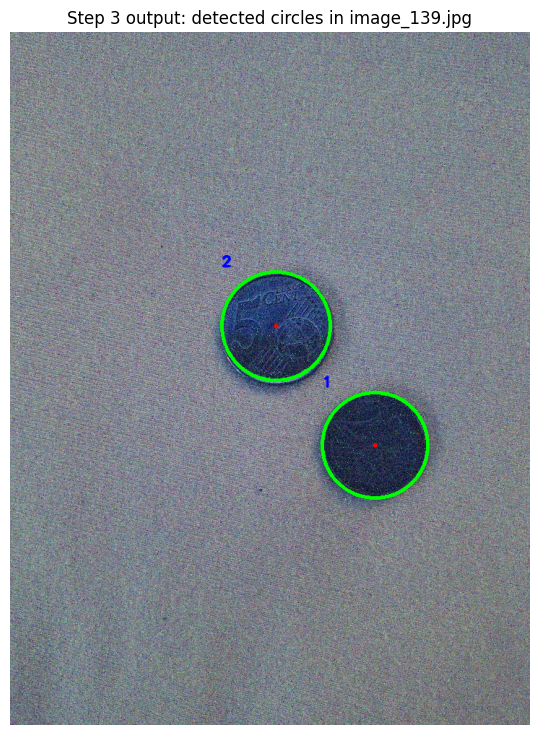

In [112]:
DEBUG_IMAGE = TARGET_DIR / "image_139.jpg"
debug_img = read_bgr(DEBUG_IMAGE)
debug_detections = select_coin_detections(debug_img)

show_rgb(draw_circles(debug_img, debug_detections), f"Step 3 output: detected circles in {DEBUG_IMAGE.name}", size=(7, 9))

Estimated pixels/mm scale: 3.739


,coin,x,y,radius,prediction,center_s,outer_s,center-outer_s,outer-center_s,all_v,Lab ring distance
0,1,367,469,100,2euro,68.0,69.0,-1.0,1.0,196.0,28.4
1,2,352,686,76,10cent,115.0,115.0,0.0,0.0,203.0,4.2
2,3,437,587,46,1cent,174.0,168.0,6.0,-6.0,174.0,6.8
3,4,128,152,103,2euro,133.0,131.0,2.0,-2.0,171.0,12.3


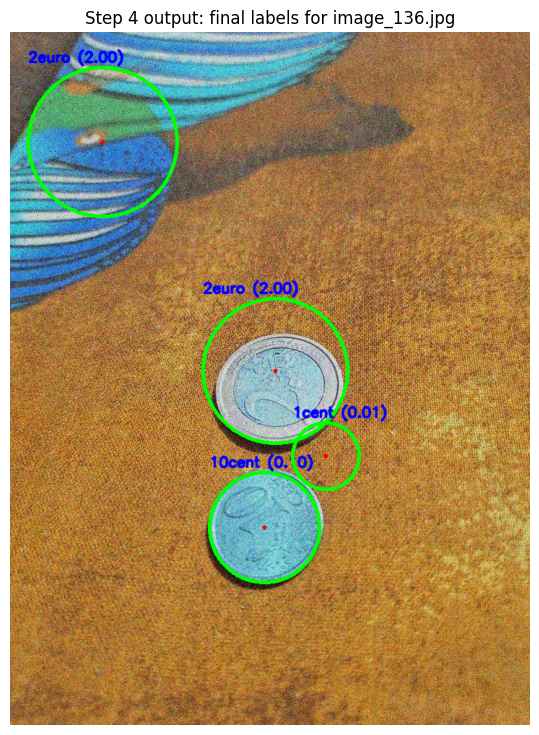

In [111]:
debug_labels, debug_details, debug_scale, debug_features, debug_sift_data = classify_detections_in_image(debug_img, debug_detections)

feature_rows = []
for i, (detection, label, features) in enumerate(zip(debug_detections, debug_labels, debug_features), start=1):
    feature_rows.append({
        "coin": i,
        "x": detection[0],
        "y": detection[1],
        "radius": detection[2],
        "prediction": label,
        "center_s": round(features["center_s"], 1),
        "outer_s": round(features["outer_s"], 1),
        "center-outer_s": round(features["center_minus_outer_s"], 1),
        "outer-center_s": round(features["outer_minus_center_s"], 1),
        "all_v": round(features["all_v"], 1),
        "Lab ring distance": round(features["center_outer_lab_distance"], 1),
    })

print("Estimated pixels/mm scale:", round(debug_scale, 3))
display(pd.DataFrame(feature_rows))

label_text = [f"{label} ({cents_to_euro(COIN_VALUES_CENTS[label]):.2f})" for label in debug_labels]
show_rgb(draw_circles(debug_img, debug_detections, label_text), f"Step 4 output: final labels for {DEBUG_IMAGE.name}", size=(7, 9))

### Step 4.5 output: SIFT keypoints on the target coin crops

Before showing matches, this cell shows the detected SIFT keypoints on each target coin crop from `image_58.jpg`.


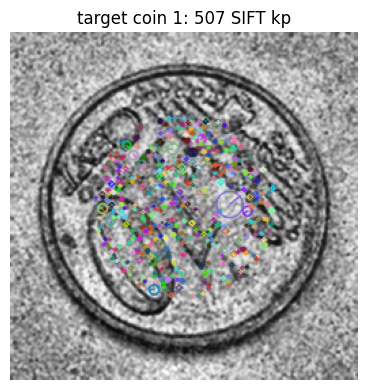

In [102]:
plt.figure(figsize=(12, 4))
for i, detection in enumerate(debug_detections, start=1):
    crop = crop_coin(debug_img, *detection[:3])
    target_gray, target_mask = normalized_gray_patch(crop)
    target_keypoints, _ = sift.detectAndCompute(target_gray, target_mask)
    keypoint_img = cv2.drawKeypoints(
        target_gray,
        target_keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    plt.subplot(1, len(debug_detections), i)
    plt.imshow(keypoint_img, cmap="gray")
    plt.title(f"target coin {i}: {len(target_keypoints)} SIFT kp")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Step 5 output: score table for `image_58.jpg`

The table below is now long-form instead of wide-form.  Each target coin is compared with each reference coin.  The table includes RootSIFT inliers, ORB inliers, the rotation-tolerant template score, and the final keypoint/template evidence used by the classifier.

In [104]:
# give me a table saying number of keypoints test, matching each target coin to each reference coin
match_rows = []
for i, (detection, label, appearance_data) in enumerate(zip(debug_detections, debug_labels, debug_sift_data), start=1):
    appearance, target_kp, target_des, _, _ = appearance_data
    for ref_label in CLASS_NAMES:
        sift_detail = appearance["sift_details"][ref_label]
        orb_detail = appearance["orb_details"][ref_label]
        match_rows.append({
            "coin": i,
            "prediction": label,
            "reference": ref_label,
            "target_sift_kp": len(target_kp),
            "target_orb_kp": len(appearance["orb_keypoints"]),
            "sift_ratio_matches": sift_detail["ratio_matches"],
            "sift_inliers": sift_detail["inliers"],
            "orb_ratio_matches": orb_detail["ratio_matches"],
            "orb_inliers": orb_detail["inliers"],
            "template_corr": round(appearance["template_scores"][ref_label], 3),
            "template_centered": round(appearance["template_centered"][ref_label], 3),
            "keypoint_z_score": round(
                0.40 * appearance["orb_z"][ref_label]
                + 0.08 * appearance["sift_z"][ref_label],
                3,
            ),
        })

match_df = pd.DataFrame(match_rows)
display(match_df.sort_values(["coin", "template_centered", "keypoint_z_score"], ascending=[True, False, False]))

,coin,prediction,reference,target_sift_kp,target_orb_kp,sift_ratio_matches,sift_inliers,orb_ratio_matches,orb_inliers,template_corr,template_centered,keypoint_z_score
4,1,20cent,20cent,507,2386,2,0,8,3,0.115,0.042,-0.069
7,1,20cent,2euro,507,2386,3,0,10,3,0.093,0.020,0.042
6,1,20cent,1euro,507,2386,3,0,8,3,0.091,0.017,-0.062
1,1,20cent,2cent,507,2386,3,0,10,3,0.079,0.005,0.042
0,1,20cent,1cent,507,2386,4,3,18,4,0.073,-0.001,1.044
5,1,20cent,50cent,507,2386,3,0,5,3,0.064,-0.010,-0.219
2,1,20cent,5cent,507,2386,1,0,7,2,0.043,-0.031,-0.545
3,1,20cent,10cent,507,2386,8,3,9,2,0.032,-0.042,-0.234


In [105]:
for coin_index, rows in enumerate(debug_details, start=1):
    print(f"Coin {coin_index}: predicted {rows[0]['label']}")
    display(pd.DataFrame(rows[:5]))

Coin 1: predicted 20cent


,label,total_score,size_score,material_score,template_score,keypoint_score,sift_inliers,sift_ratio_matches,orb_inliers,orb_ratio_matches
0,20cent,1.631113,-0.000000,1.499587,0.041693,-0.068870,0,2,3,8
1,50cent,0.426730,-0.878177,1.499587,-0.009590,-0.218765,0,3,3,5
2,10cent,-0.375893,-1.674913,1.499587,-0.042035,-0.233689,3,8,2,9
3,1euro,-0.616202,-0.229104,-0.804806,0.017032,-0.062186,0,3,3,8
4,2euro,-1.730160,-2.527042,-0.931262,0.019681,0.042200,0,3,3,10


### Step 6 output: SIFT matches for the chosen denomination

These images show the actual SIFT correspondences between each detected coin crop and the chosen reference coin.

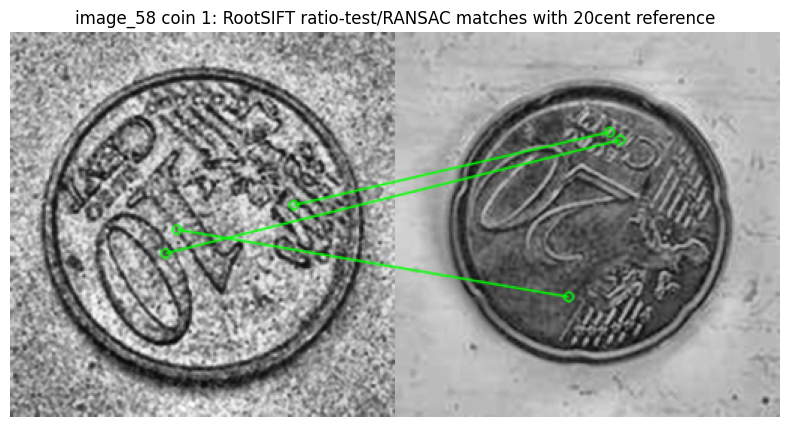

In [92]:
def draw_sift_matches_to_reference(img_bgr, detection, predicted_label, max_matches=25):
    """Draw RootSIFT matches between one target crop and one reference crop.

    Both sides are displayed after the same affine normalization, CLAHE, mask,
    RootSIFT descriptor conversion, Lowe ratio test, and RANSAC geometry check.
    """
    crop = crop_coin(img_bgr, *detection[:3])
    target_gray, target_mask = normalized_gray_patch(crop)
    target_kp, target_des = sift.detectAndCompute(target_gray, target_mask)
    target_des = rootsift(target_des)

    ref = reference_db[predicted_label]
    ref_gray = ref["gray"]
    ref_kp = ref["keypoints"]
    ref_des = ref["descriptors"]

    detail = match_descriptors_with_geometry(
        target_kp,
        target_des,
        ref_kp,
        ref_des,
        sift_matcher,
        SIFT_RATIO,
    )

    if not detail["matches"]:
        return cv2.cvtColor(cv2.hconcat([target_gray, ref_gray]), cv2.COLOR_GRAY2RGB)

    if detail["ransac_mask"]:
        pairs = sorted(
            zip(detail["matches"], detail["ransac_mask"]),
            key=lambda pair: pair[0].distance,
        )[:max_matches]
        matches_to_draw = [pair[0] for pair in pairs]
        mask_to_draw = [pair[1] for pair in pairs]
    else:
        matches_to_draw = sorted(detail["matches"], key=lambda m: m.distance)[:max_matches]
        mask_to_draw = None

    draw_params = dict(
        matchColor=(0, 255, 0),
        singlePointColor=None,
        matchesMask=mask_to_draw,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    return cv2.drawMatches(
        target_gray,
        target_kp,
        ref_gray,
        ref_kp,
        matches_to_draw,
        None,
        **draw_params,
    )


for i, (detection, label) in enumerate(zip(debug_detections, debug_labels), start=1):
    match_img = draw_sift_matches_to_reference(debug_img, detection, label)
    plt.figure(figsize=(12, 5))
    plt.imshow(match_img, cmap="gray")
    plt.title(f"image_58 coin {i}: RootSIFT ratio-test/RANSAC matches with {label} reference")
    plt.axis("off")
    plt.show()

## 8. Run the complete pipeline on all target images

In [17]:
def predict_image(path):
    img = read_bgr(path)
    detections = select_coin_detections(img)
    labels, details, scale, features, sift_data = classify_detections_in_image(img, detections)
    cents = [COIN_VALUES_CENTS[label] for label in labels]
    return {
        "image": Path(path).name,
        "path": path,
        "detections": detections,
        "labels": labels,
        "coin_cents": cents,
        "total_cents": int(sum(cents)),
        "scale": scale,
        "details": details,
    }


all_predictions = [predict_image(path) for path in target_paths]

summary_df = pd.DataFrame([
    {
        "image": p["image"],
        "coins_found": len(p["coin_cents"]),
        "predicted_labels": p["labels"],
        "predicted_values_cents": p["coin_cents"],
        "partial_amount_euro": cents_to_euro(p["total_cents"]),
    }
    for p in all_predictions
])

summary_df.head(12)

,image,coins_found,predicted_labels,predicted_values_cents,partial_amount_euro
0,image_1.jpg,3,"[1cent, 2cent, 5cent]","[1, 2, 5]",0.08
1,image_2.jpg,1,[10cent],[10],0.10
2,image_3.jpg,6,"[5cent, 2cent, 1cent, 2cent, 2cent, 1cent]","[5, 2, 1, 2, 2, 1]",0.13
3,image_4.jpg,1,[1cent],[1],0.01
4,image_5.jpg,1,[10cent],[10],0.10
5,image_6.jpg,1,[2cent],[2],0.02
6,image_7.jpg,3,"[5cent, 50cent, 50cent]","[5, 50, 50]",1.05
7,image_8.jpg,1,[2cent],[2],0.02
8,image_9.jpg,1,[2cent],[2],0.02
9,image_10.jpg,1,[50cent],[50],0.50


## 9. Required assignment-style output

In [18]:
def print_assignment_output(predictions, max_images=None):
    rows = predictions if max_images is None else predictions[:max_images]
    for prediction in rows:
        print(f"{prediction['image']} - {len(prediction['coin_cents'])} coin(s) found:")
        for i, cents in enumerate(prediction["coin_cents"], start=1):
            print(f"  Coin {i} {{value: {cents_to_euro(cents):.3f}}}")
        print(f"  Partial Amount {{value: {cents_to_euro(prediction['total_cents']):.3f}}}")
        print()
    total_amount = cents_to_euro(sum(p["total_cents"] for p in predictions))
    print(f"Total Amount: {total_amount:.3f} euros")


print_assignment_output(all_predictions)

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.010}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.050}
  Partial Amount {value: 0.080}

image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}

image_3.jpg - 6 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.010}
  Coin 4 {value: 0.020}
  Coin 5 {value: 0.020}
  Coin 6 {value: 0.010}
  Partial Amount {value: 0.130}

image_4.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Partial Amount {value: 0.010}

image_5.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}

image_6.jpg - 1 coin(s) found:
  Coin 1 {value: 0.020}
  Partial Amount {value: 0.020}

image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.500}
  Coin 3 {value: 0.500}
  Partial Amount {value: 1.050}

image_8.jpg - 1 coin(s) found:
  Coin 1 {value: 0.020}
  Partial Amount {value: 0.020}

image_9.jpg - 1 coin(s) found:
  Coin 1 {value: 0.020}
  Partial Amount {value: 

## 10. Ten random visual predictions

The next cell draws ten random target images with circles and predicted labels.  A fixed seed makes the sample reproducible.

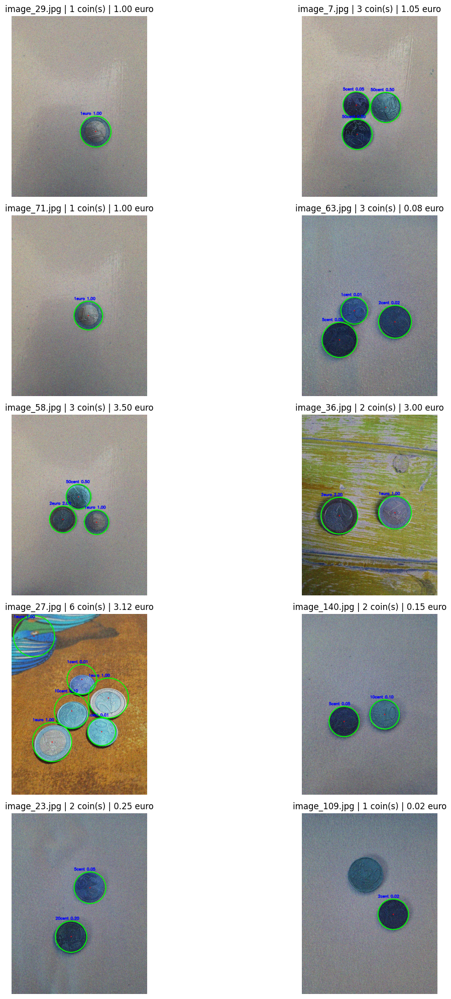

In [19]:
def draw_prediction_overlay(prediction):
    img = read_bgr(prediction["path"])
    labels = [f"{label} {cents_to_euro(COIN_VALUES_CENTS[label]):.2f}" for label in prediction["labels"]]
    return draw_circles(img, prediction["detections"], labels)


random.seed(42)
random_predictions = random.sample(all_predictions, k=min(10, len(all_predictions)))

plt.figure(figsize=(15, 20))
for i, prediction in enumerate(random_predictions, start=1):
    overlay = cv2.cvtColor(draw_prediction_overlay(prediction), cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, i)
    plt.imshow(overlay)
    plt.title(
        f"{prediction['image']} | {len(prediction['coin_cents'])} coin(s) | "
        f"{cents_to_euro(prediction['total_cents']):.2f} euro"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

## 11. Text output for the ten random images

In [20]:
print_assignment_output(random_predictions)

image_29.jpg - 1 coin(s) found:
  Coin 1 {value: 1.000}
  Partial Amount {value: 1.000}

image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.500}
  Coin 3 {value: 0.500}
  Partial Amount {value: 1.050}

image_71.jpg - 1 coin(s) found:
  Coin 1 {value: 1.000}
  Partial Amount {value: 1.000}

image_63.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.010}
  Partial Amount {value: 0.080}

image_58.jpg - 3 coin(s) found:
  Coin 1 {value: 2.000}
  Coin 2 {value: 0.500}
  Coin 3 {value: 1.000}
  Partial Amount {value: 3.500}

image_36.jpg - 2 coin(s) found:
  Coin 1 {value: 2.000}
  Coin 2 {value: 1.000}
  Partial Amount {value: 3.000}

image_27.jpg - 6 coin(s) found:
  Coin 1 {value: 0.010}
  Coin 2 {value: 1.000}
  Coin 3 {value: 1.000}
  Coin 4 {value: 0.100}
  Coin 5 {value: 0.010}
  Coin 6 {value: 1.000}
  Partial Amount {value: 3.120}

image_140.jpg - 2 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.100}
  Partial

In [21]:
# Private answer-key evaluation is intentionally not included in this notebook.
# Keep any ground-truth checks in a separate scratch file and remove them before submission.


## Conclusion

The final notebook now exposes the important intermediate results instead of only printing final labels.  For each decision you can inspect the circle detector, the reference keypoints, the target material features, the denomination score table, and the SIFT matches to the selected reference.